In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from db import engine

plt.rcParams["figure.figsize"] = (15, 6)
sns.set_style('whitegrid')

In [2]:
with engine.connect() as conn:
    loc_df = pd.read_sql("select * from location", conn)
    weather_df = pd.read_sql("select * from weather_observation", conn)

In [3]:
def to_f(temp):
    return (temp * (9/5)) + 32

In [13]:
df = loc_df.merge(weather_df, left_on='id', right_on='location_id', suffixes=['_loc', '_wea'])

In [14]:
df['observed_date'] = df['observed_at'].dt.strftime('%Y-%m-%d')

In [23]:
df['year'] = df['observed_at'].dt.year

In [24]:
df['month'] = df['observed_at'].dt.month_name()

In [25]:
df['month'] = pd.Categorical(df['month'], categories=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], ordered=True)

In [26]:
df['month'].value_counts()

month
January      66960
March        66960
May          66960
July         66960
August       66960
October      66960
December     66960
April        64800
June         64800
September    64800
November     64800
February     61200
Name: count, dtype: int64

In [27]:
df['temperature_f'] = df['temperature'].apply(to_f)
df['feels_like_f'] = df['feels_like'].apply(to_f)

In [28]:
# df[]

In [29]:
seattle_df = df[df['city'] == 'Seattle']
sv_df = df[df['city'] == 'Spokane Valley']

In [30]:
# seattle_df.groupby('month')['temperature_f'].mean()

In [31]:
# sv_df.groupby('month')['temperature_f'].mean()

In [33]:
seattle_pivot = pd.pivot_table(seattle_df, columns='month', index='year', values='temperature_f')

In [34]:
spokane_valley_pivot = pd.pivot_table(sv_df, columns='month', index='year', values='temperature_f')

In [35]:
seattle_pivot

month,January,February,March,April,May,June,July,August,September,October,November,December
year,,,,,,,,,,,,
2023,42.229032,39.799464,42.851290,46.95025,59.265645,60.03775,65.686613,66.657258,58.9840,52.448387,43.7165,43.910484
2024,40.341452,43.097931,45.011774,48.91325,54.342258,59.58675,68.283306,64.420806,60.5545,52.266452,45.0795,42.773387
2025,38.287177,39.590536,45.778710,50.32475,55.181048,61.14125,65.261774,66.134919,61.2385,51.027258,47.5895,43.790968


In [36]:
spokane_valley_pivot

month,January,February,March,April,May,June,July,August,September,October,November,December
year,,,,,,,,,,,,
2023,31.143065,30.427946,36.357016,44.62450,62.032661,65.47375,73.494355,71.469113,60.32225,49.068306,35.13175,33.642984
2024,27.323871,35.360259,40.075323,47.43200,54.697419,62.35400,76.151048,70.595000,65.16375,49.092258,37.29975,33.975645
2025,27.922661,28.479821,42.362097,48.51675,56.550645,66.31275,73.385726,72.902581,67.61550,47.123871,40.21575,36.441210


<Axes: xlabel='month', ylabel='year'>

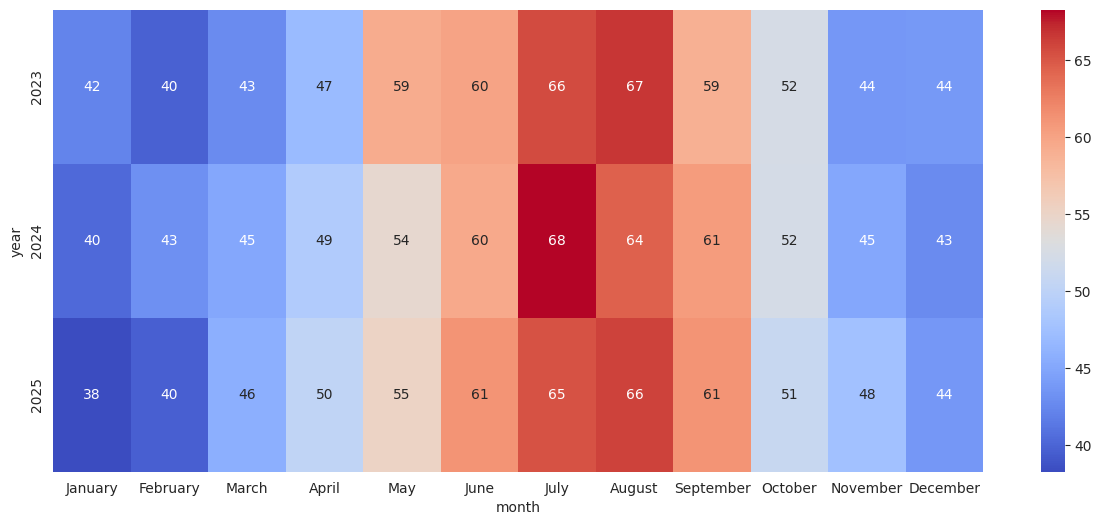

In [38]:
sns.heatmap(seattle_pivot, cmap='coolwarm', annot=True)

<Axes: xlabel='month', ylabel='year'>

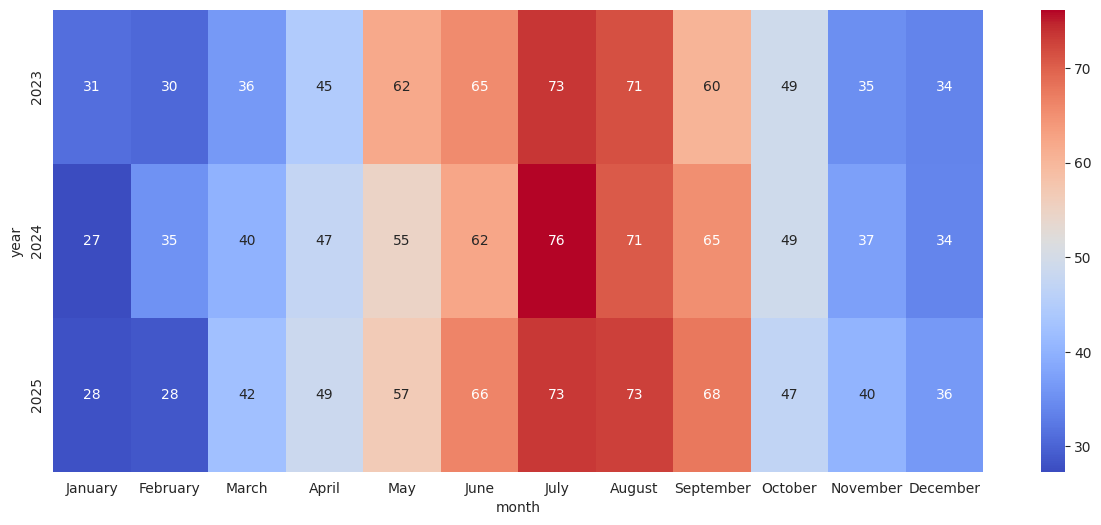

In [39]:
sns.heatmap(spokane_valley_pivot, cmap='coolwarm', annot=True)

In [40]:
df['city'].value_counts()

city
Seattle           26304
Bothell           26304
Portland          26304
Spokane Valley    26304
Olympia           26304
Bellingham        26304
Yakima            26304
Bend              26304
San Francisco     26304
Los Angeles       26304
San Diego         26304
Phoenix           26304
Las Vegas         26304
Albuquerque       26304
Denver            26304
Salt Lake City    26304
Boise             26304
Chicago           26304
Minneapolis       26304
Kansas City       26304
Dallas            26304
Houston           26304
New Orleans       26304
Atlanta           26304
Miami             26304
New York          26304
Boston            26304
Philadelphia      26304
Anchorage         26304
Honolulu          26304
Name: count, dtype: int64

In [43]:
df.groupby('city')['temperature_f'].mean().sort_values(ascending=False)

city
Phoenix           76.421241
Miami             76.256337
Honolulu          75.261341
New Orleans       70.920812
Houston           70.815682
Las Vegas         70.690023
Dallas            69.416549
Los Angeles       63.652108
Atlanta           63.212742
San Diego         62.785324
Albuquerque       60.055338
Kansas City       57.616017
Philadelphia      57.215520
San Francisco     56.548985
New York          56.385388
Salt Lake City    55.630782
Boise             55.205315
Portland          54.144366
Yakima            54.098784
Denver            53.136868
Bothell           53.104302
Olympia           52.699028
Boston            52.316727
Seattle           52.080935
Bellingham        51.866932
Chicago           51.128894
Spokane Valley    50.117475
Bend              49.764147
Minneapolis       49.218577
Anchorage         37.360249
Name: temperature_f, dtype: float64